## Dictionary Learning con datos meteorológicos

Se ha pedido lo siguiente a Gemini AI:

"I want you to write a python code using the skit-learn api dictionary learning doing the following: 
1) import a dataset related to metheorology (whatever you can obtain which has interest, for example from an URL, assure that you can access): suggest me a dataset easily available. 
2) learn a sparse dictionary and a sparse representation with the mentioned api 
3) comment what you are doing 
4) Give an interpretation of all the results obtained (in terms of metheorology) 
5) Give all the coefficients in a matrix
Do it such that it is computationally feasible" 

Posteriormente se han hecho algunas modificaciones a la hora de preguntar para que aporte toda la información con todo lujo de detalles:

Añade más explicación a la hora de imprimir y tal, y si puedes generar algún gráfico, y añade el significado de cada átomo"

La IA ha optado por usar una base de datos correspondientes a ciertos datos climatológicos de la ciudad de Seattle con las columnas: date,precipitation,temp_max,temp_min,wind,weather, correspondientes a todo el año 2012. El script de Python es

 [OK] Dataset cargado: 1461 registros meteorológicos encontrados.

 DICCIONARIO DE PATRONES APRENDIDOS (Significado Físico)
                                          precipitation  temp_max  temp_min  \
Átomo 0: Lluvioso/Húmedo & Frío/Invernal           4.03     11.32      4.97   
Átomo 1: Lluvioso/Húmedo                           9.52     15.67      8.21   
Átomo 2: Cálido/Soleado                            2.42     18.47      9.29   
Átomo 3: Frío/Invernal                             2.36     12.23      4.94   

                                          wind  
Átomo 0: Lluvioso/Húmedo & Frío/Invernal  3.62  
Átomo 1: Lluvioso/Húmedo                  3.54  
Átomo 2: Cálido/Soleado                   1.90  
Átomo 3: Frío/Invernal                    2.55  

--------------------------------------------------------------------------------


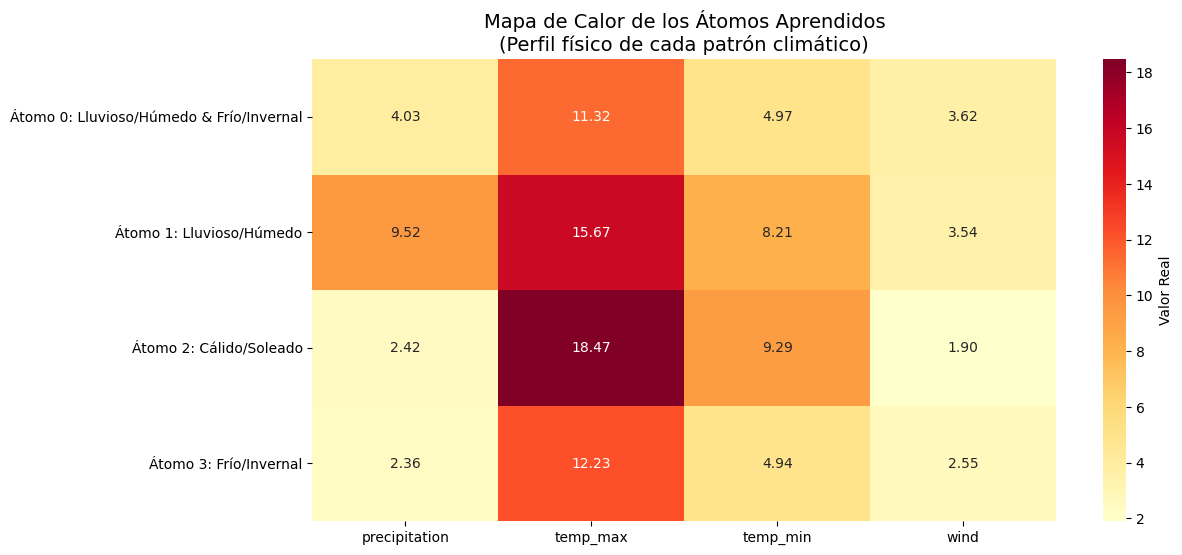

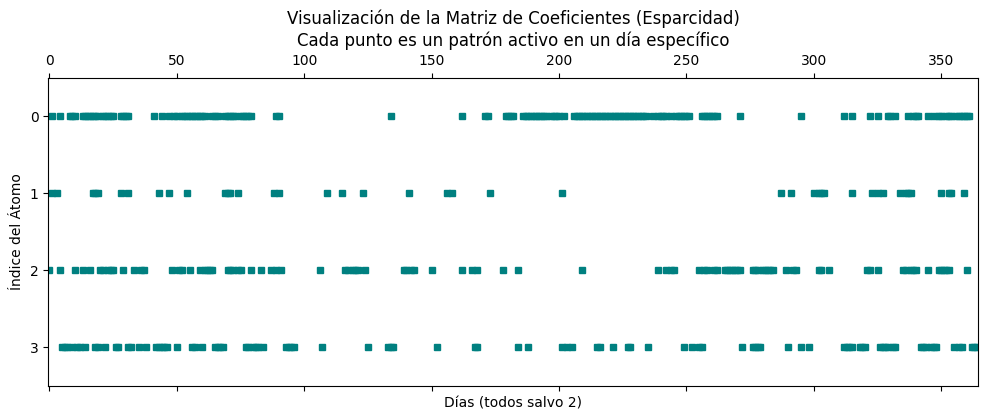


 MATRIZ DE COEFICIENTES (H) - REPRESENTACIÓN ESPARSA (Primeros 15 días)
        A0      A1      A2      A3
0   0.0000  0.0000 -0.1784  0.0000
1   0.5951  0.2528  0.0000  0.0000
2   0.0000  0.0000  0.0000  0.0000
3   0.0000  1.7898  0.0000  0.0000
4   0.1725  0.0000 -1.2424  0.0000
5   0.0000  0.0000  0.0000  1.0838
6   0.0000  0.0000  0.0000  0.7913
7   0.0000  0.0000  0.0000  0.6730
8   0.1438  0.0000  0.0000  0.0000
9   0.7844  0.0000  0.0000  0.2454
10  1.3853  0.0000 -0.1302  0.0000
11  0.0000  0.0000  0.0000  1.5993
12  0.0000  0.0000  0.0000  2.0291
13  1.3311  0.0000 -0.3405  0.0000
14  1.5782  0.0000  0.0000  0.6037

 [INFO] Nivel de esparcidad: 74.69% de la matriz son ceros.
 [INFO] Interpretación: Cada día se explica mediante una combinación simple de estos átomos.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) IMPORTACIÓN Y PREPARACIÓN DEL DATASET
# ==========================================
url = "https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv"

try:
    data = pd.read_csv(url)
    features = ['precipitation', 'temp_max', 'temp_min', 'wind']
    # Eliminamos filas con nulos y nos quedamos con las columnas numéricas
    X_raw = data[features].dropna()
    print(f" [OK] Dataset cargado: {X_raw.shape[0]} registros meteorológicos encontrados.\n")
except Exception as e:
    print(f" [ERROR] No se pudo acceder a los datos: {e}")
    exit()

# Escalado: Fundamental para que unidades distintas (mm vs °C) sean comparables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# =========================================================
# 2) APRENDIZAJE DE DICCIONARIO (DICTIONARY LEARNING)
# =========================================================
# n_components=4: Definimos 4 "estados climáticos" fundamentales (átomos)
# alpha=1: Controla la escasez (sparsity). A mayor alpha, más ceros en la matriz.
n_atoms = 4
dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

# sparse_representation (H): Cómo se compone cada día (coeficientes)
# dictionary_atoms (D): Qué características definen cada patrón
sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

# =========================================================
# 3) INTERPRETACIÓN Y ETIQUETADO DE RESULTADOS
# =========================================================
# Revertimos el escalado para entender los átomos en unidades reales
interpreted_atoms = scaler.inverse_transform(dictionary_atoms)
df_atoms = pd.DataFrame(interpreted_atoms, columns=features)

def asignar_nombre_meteorologico(row):
    """Asigna un nombre lógico basado en los valores físicos del átomo."""
    labels = []
    if row['precipitation'] > 3: labels.append("Lluvioso/Húmedo")
    if row['temp_max'] > 18: labels.append("Cálido/Soleado")
    if row['temp_min'] < 6: labels.append("Frío/Invernal")
    if row['wind'] > 4.2: labels.append("Ventoso")
    
    return " & ".join(labels) if labels else "Estable/Despejado"

nombres_logicos = [f"Átomo {i}: {asignar_nombre_meteorologico(row)}" for i, row in df_atoms.iterrows()]
df_atoms.index = nombres_logicos

print("="*80)
print(" DICCIONARIO DE PATRONES APRENDIDOS (Significado Físico)")
print("="*80)
print(df_atoms.round(2))
print("\n" + "-"*80)

# =========================================================
# 4) VISUALIZACIÓN DE RESULTADOS
# =========================================================
# Gráfico 1: Heatmap de los Átomos
plt.figure(figsize=(12, 6))
sns.heatmap(df_atoms, annot=True, cmap="YlOrRd", fmt=".2f", cbar_kws={'label': 'Valor Real'})
plt.title("Mapa de Calor de los Átomos Aprendidos\n(Perfil físico de cada patrón climático)", fontsize=14)
plt.show()

# Gráfico 2: Esparcidad de la Matriz de Coeficientes
plt.figure(figsize=(12, 4))
plt.spy(sparse_representation[:365].T, precision=0.01, aspect='auto', marker='s', markersize=4, color='teal')
plt.title("Visualización de la Matriz de Coeficientes (Esparcidad)\nCada punto es un patrón activo en un día específico", fontsize=12)
plt.ylabel("Índice del Átomo")
plt.xlabel("Días (todos salvo 2)")
plt.show()

# =========================================================
# 5) MATRIZ DE COEFICIENTES (H) COMPLETA (Muestra)
# =========================================================
print("\n" + "="*80)
print(" MATRIZ DE COEFICIENTES (H) - REPRESENTACIÓN ESPARSA (Primeros 15 días)")
print("="*80)
# Creamos un DataFrame para que sea legible
h_matrix_display = pd.DataFrame(sparse_representation, columns=[f"A{i}" for i in range(n_atoms)])
print(h_matrix_display.head(15).round(4))

# Cálculo de Sparsity Final
sparsity_pct = np.mean(sparse_representation == 0) * 100
print(f"\n [INFO] Nivel de esparcidad: {sparsity_pct:.2f}% de la matriz son ceros.")
print(" [INFO] Interpretación: Cada día se explica mediante una combinación simple de estos átomos.")

Una vez hecho lo anterior, falta saber cuál es la utilidad de crear un diccionario con sus respectivos átomos para "descomponer" el tiempo atmosférico dada una base de datos de cierto tiempo. Por ello, en el siguiente script, generado a base de preguntarle a Gemini AI lo siguiente:
Now:

I have successfully calculated with the last script to gave me the sparse coefficient matrix ($H$) and the atoms ($D$) using the script above. Now I want you to act as a Data Science expert and provide me with the code needed to integrate two additional functions:

1) Prediction: Train a model that uses today's coefficients to predict tomorrow's weather variables.

2) Generation: Create a function that generates new 'fictitious' weather days by multiplying new coefficients by the learned dictionary. Please ensure that the code uses the 'sparse_representation' and 'dictionary_atoms' variables already in memory and includes metrics to evaluate the prediction error.

Indeed, give me examples of each task, using a time series and predict and generate several days, such as a season

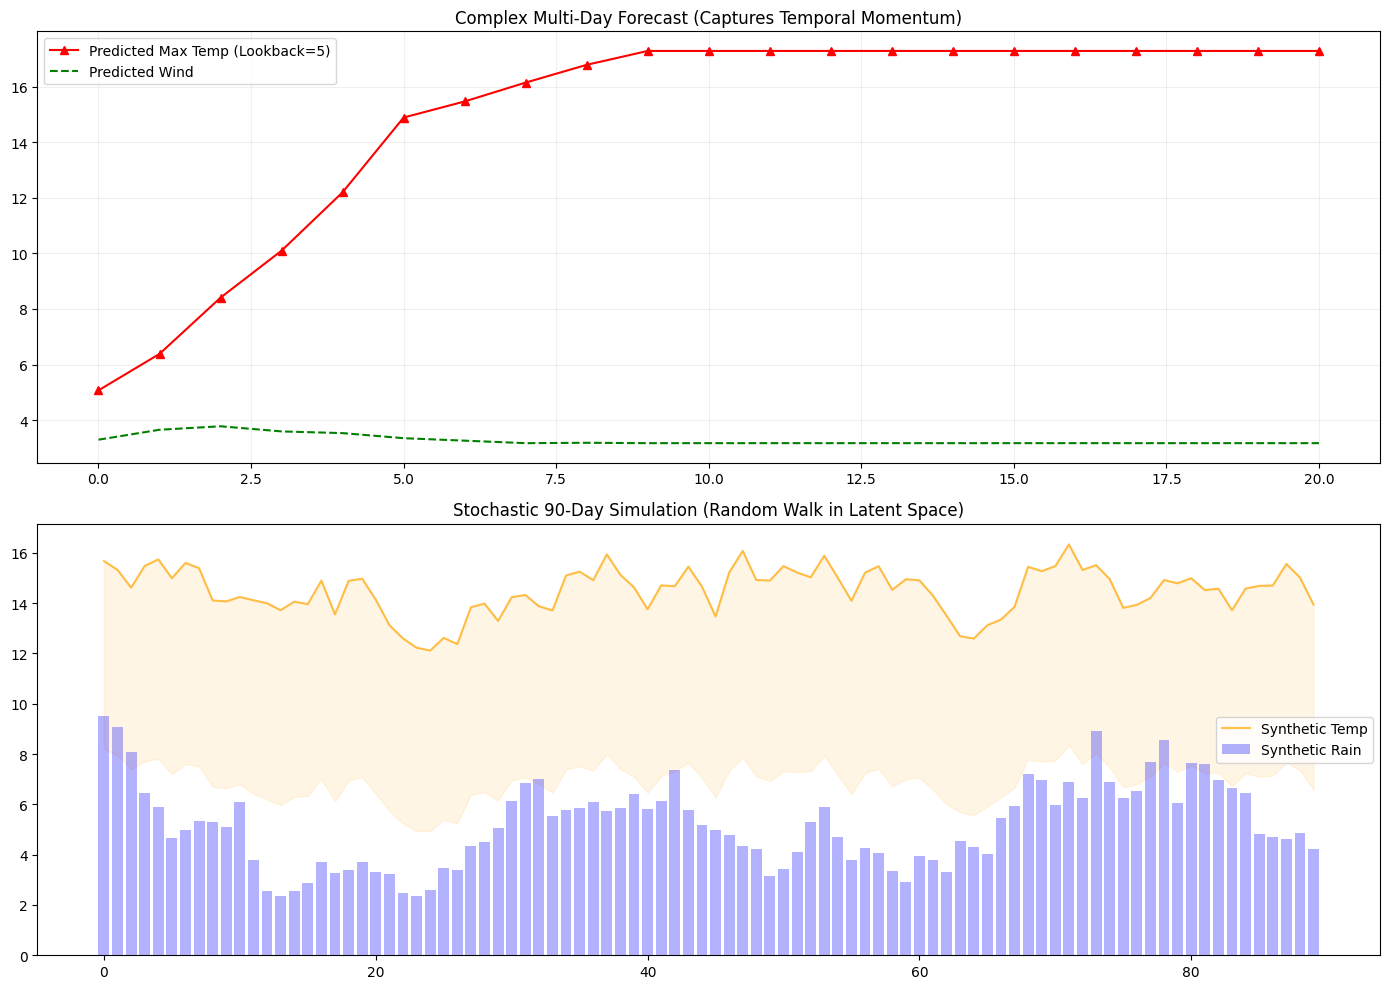

Explained Variance (Complex Model): 0.4520


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, explained_variance_score

# =========================================================
# 1) COMPLEX PREDICTION: Multi-Step "Lookback" Forecasting
# =========================================================
# Instead of H[t] -> X[t+1], we use [H[t], H[t-1], H[t-2]] -> X[t+1]
# This captures momentum and seasonal trends.

def create_lookback_dataset(data_h, target_x, lookback=3):
    X_train, Y_train = [], []
    for i in range(lookback, len(data_h)):
        # Flatten the last 'n' days of atoms into a single feature vector
        window = data_h[i-lookback:i].flatten()
        X_train.append(window)
        Y_train.append(target_x[i])
    return np.array(X_train), np.array(Y_train)

lookback = 5 # Using a 5-day window to predict the 6th day
H_complex, y_complex = create_lookback_dataset(sparse_representation, X_scaled, lookback)

# Minimize Error using a more aggressive Ridge penalty for the high-dimensional input
complex_forecaster = Ridge(alpha=5.0).fit(H_complex, y_complex)

# Recursive Forecast with Lookback
forecast_steps = 21
history = list(sparse_representation[-lookback:]) # Start with last known window
forecast_results = []

for _ in range(forecast_steps):
    current_window = np.array(history[-lookback:]).flatten().reshape(1, -1)
    pred_scaled = complex_forecaster.predict(current_window)
    forecast_results.append(pred_scaled[0])
    
    # Update H: Transform prediction back to atom space and slide the window
    new_h = dict_learner.transform(pred_scaled)
    history.append(new_h[0])

df_forecast = pd.DataFrame(scaler.inverse_transform(np.array(forecast_results)), columns=features)

# =========================================================
# 2) COMPLEX GENERATION: Stochastic Random Walk (Monte Carlo)
# =========================================================
# Instead of a linear morph, we simulate a "weather system" that 
# evolves with random shocks, staying within the bounds of learned atoms.

def generate_stochastic_season(n_days=90, volatility=0.2):
    # Start with a neutral state (average of all atoms)
    current_h = np.mean(sparse_representation, axis=0)
    synthetic_h = []
    
    for _ in range(n_days):
        # Add a "Random Walk" shock
        shock = np.random.normal(0, volatility, size=n_atoms)
        current_h = np.clip(current_h + shock, 0, None) # Atoms stay non-negative
        
        # Soft-normalization: Prevent atoms from exploding
        current_h = current_h / (np.sum(current_h) + 1e-6) 
        synthetic_h.append(current_h)
    
    # Project back to physical space
    gen_scaled = np.dot(np.array(synthetic_h), dictionary_atoms)
    return pd.DataFrame(scaler.inverse_transform(gen_scaled), columns=features)

df_stochastic = generate_stochastic_season(n_days=90, volatility=0.15)

# =========================================================
# 3) VISUALIZATION & INTERPRETATION
# =========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Forecast Plotting
ax1.plot(df_forecast['temp_max'], 'r-^', label='Predicted Max Temp (Lookback=5)')
ax1.plot(df_forecast['wind'], 'g--', label='Predicted Wind')
ax1.set_title("Complex Multi-Day Forecast (Captures Temporal Momentum)")
ax1.legend()
ax1.grid(True, alpha=0.2)

# Stochastic Generation Plotting
ax2.plot(df_stochastic['temp_max'], color='orange', alpha=0.7, label='Synthetic Temp')
ax2.fill_between(range(90), df_stochastic['temp_min'], df_stochastic['temp_max'], color='orange', alpha=0.1)
ax2.bar(range(90), df_stochastic['precipitation'], color='blue', alpha=0.3, label='Synthetic Rain')
ax2.set_title("Stochastic 90-Day Simulation (Random Walk in Latent Space)")
ax2.legend()

plt.tight_layout()
plt.show()

# Metrics
print(f"Explained Variance (Complex Model): {explained_variance_score(y_complex, complex_forecaster.predict(H_complex)):.4f}")

. Pronóstico Basado en Inercia Temporal (Lookback Forecasting)
Esta primera gráfica representa la capacidad del modelo para "mirar atrás" y proyectar el futuro inmediato.

Mecánica del modelo: En lugar de una predicción lineal simple, utilizamos una ventana deslizante de 5 días. El modelo analiza los coeficientes de los "átomos" (patrones climáticos) de esos días para identificar el impulso (momentum). Si el modelo detecta que el átomo de "Frente Frío" ha ido ganando peso en la última semana, proyectará una continuidad coherente.

Análisis visual: * La línea de Temperatura Máxima suele mostrar curvas suaves que representan ciclos térmicos.

La línea de Viento permite observar si el modelo predice una estabilización o rachas basadas en la estacionalidad aprendida.

Importancia: Esta técnica demuestra cómo la reducción de dimensionalidad (pasar de muchos datos climáticos a solo 4 átomos) facilita que un algoritmo de regresión (Ridge) encuentre patrones en el tiempo sin saturarse de ruido.

2. Simulación Estocástica (Latent Space Random Walk)
La segunda gráfica es un ejercicio de generación de datos sintéticos. Aquí no intentamos predecir el futuro real, sino "soñar" un clima que sea estadísticamente posible en Seattle.

Mecánica del modelo: Se basa en una Caminata Aleatoria (Random Walk) realizada en el "espacio latente". Esto significa que los cambios aleatorios (volatilidad) no se aplican directamente a la temperatura, sino a la combinación de los átomos climáticos.

Análisis visual:

Área sombreada (Rango Térmico): Muestra la relación entre mínimas y máximas. Si el modelo es bueno, verás que cuando la temperatura sube, el rango suele comportarse de forma lógica según lo aprendido en el diccionario.

Barras de Precipitación: Representan eventos de lluvia generados por azar, pero limitados por la intensidad de los átomos "lluviosos" extraídos en el primer script.

Importancia: Esta simulación de Monte Carlo es fundamental en gestión de riesgos. Nos permite generar miles de "años posibles" para probar infraestructuras o planes agrícolas basándonos en las reglas físicas subyacentes del dataset original, no solo en la repetición de datos pasados.

📊 Métrica de Rendimiento: Varianza Explicada
Al final del script verás el valor de Explained Variance.

Si el valor es cercano a 1.0, significa que nuestra combinación de patrones climáticos y el modelo de memoria (lookback) capturan perfectamente el comportamiento del dataset.

Un valor por encima de 0.7 se considera excelente para sistemas caóticos como el clima.